In [ ]:
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 44.2 MB/s eta 0:00:00


In [ ]:
import gurobipy as gp
import numpy as np


distance = np.array([
    [0, 15, 0, 0, 24, 0, 18, 0, 0, 0, 0, 0],
    [15, 0, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 22, 0, 18, 16, 0, 0, 0, 20, 0, 0, 0],
    [0, 0, 18, 0, 0, 12, 0, 0, 0, 0, 0, 0],
    [24, 0, 16, 0, 0, 0, 25, 12, 24, 0, 0, 0],
    [0, 0, 0, 12, 0, 0, 0, 0, 12, 0, 0, 22],
    [18, 0, 0, 0, 25, 0, 0, 15, 0, 22, 0, 0],
    [0, 0, 0, 0, 12, 0, 15, 0, 30, 0, 25, 0],
    [0, 0, 20, 0, 24, 12, 0, 30, 0, 0, 19, 19],
    [0, 0, 0, 0, 0, 0, 22, 0, 0, 0, 19, 0],
    [0, 0, 0, 0, 0, 0, 0, 25, 19, 19, 0, 21],
    [0, 0, 0, 0, 0, 22, 0, 0, 19, 0, 21, 0]
])

In [ ]:
import numpy as np
import networkx as nx

def djikstra(distance_matrix):
    num_nodes = distance_matrix.shape[0]

    # Build the graph
    G = nx.Graph()
    for i in range(num_nodes):
        for j in range(num_nodes):
            if distance_matrix[i, j] > 0 and i != j:
                G.add_edge(i, j, weight=distance_matrix[i, j])

    # Compute all-pairs shortest path lengths and paths
    all_pairs_dist = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    all_pairs_paths = dict(nx.all_pairs_dijkstra_path(G, weight='weight'))

    # Initialize distance matrix
    full_distance = np.full((num_nodes, num_nodes), 9999.0)
    full_paths = [[[] for _ in range(num_nodes)] for _ in range(num_nodes)]

    for start_node, distances in all_pairs_dist.items():
        for end_node, dist in distances.items():
            full_distance[start_node, end_node] = dist
            full_paths[start_node][end_node] = all_pairs_paths[start_node][end_node]

    # Self-loops: distance = 0, path = [node]
    np.fill_diagonal(full_distance, 0.0)
    for i in range(num_nodes):
        full_paths[i][i] = [i]

    return full_distance, full_paths


num_nodes = distance.shape[0]
full_distance, full_paths = djikstra(distance)

print("Node-to-Node Shortest Distance Matrix:")
print(full_distance)

Node-to-Node Shortest Distance Matrix:
[[ 0. 15. 37. 55. 24. 60. 18. 33. 48. 40. 58. 67.]
 [15.  0. 22. 40. 38. 52. 33. 48. 42. 55. 61. 61.]
 [37. 22.  0. 18. 16. 30. 41. 28. 20. 58. 39. 39.]
 [55. 40. 18.  0. 34. 12. 59. 46. 24. 62. 43. 34.]
 [24. 38. 16. 34.  0. 36. 25. 12. 24. 47. 37. 43.]
 [60. 52. 30. 12. 36.  0. 57. 42. 12. 50. 31. 22.]
 [18. 33. 41. 59. 25. 57.  0. 15. 45. 22. 40. 61.]
 [33. 48. 28. 46. 12. 42. 15.  0. 30. 37. 25. 46.]
 [48. 42. 20. 24. 24. 12. 45. 30.  0. 38. 19. 19.]
 [40. 55. 58. 62. 47. 50. 22. 37. 38.  0. 19. 40.]
 [58. 61. 39. 43. 37. 31. 40. 25. 19. 19.  0. 21.]
 [67. 61. 39. 34. 43. 22. 61. 46. 19. 40. 21.  0.]]


In [ ]:
import gurobipy as gp

def solve_technician_routing(all_nodes, farmers, technicians, office_node,
                             initial_straws, refill_amount, full_distance, full_paths,
                             origin_of=None, time_limit=None):
    if origin_of is None:
        origin_of = {t: t for t in technicians}

    # Model
    m = gp.Model("TechnicianRouting")
    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    N = len(all_nodes)
    big_M = 10**6

    # Decision variables
    x = m.addVars(all_nodes, all_nodes, technicians, vtype=gp.GRB.BINARY, name="x")

    # r[node, tech] = number of straws the technician has after arriving at node
    max_possible_refill_per_visit = max(refill_amount.values())
    r_ub = max(initial_straws.values()) + max_possible_refill_per_visit * N
    r = m.addVars(all_nodes, technicians, lb=0, ub=r_ub, vtype=gp.GRB.INTEGER, name="r")

    # visits[tech] = number of times technician visits the office
    visits = m.addVars(technicians, lb=0, ub=N, vtype=gp.GRB.INTEGER, name="visits")

    # Objective: minimize travel distance
    m.setObjective(
        gp.quicksum(full_distance[i][j] * x[i, j, t]
                    for t in technicians
                    for i in all_nodes
                    for j in all_nodes if i != j),
        gp.GRB.MINIMIZE
    )

    # -------------------
    # Constraints
    # -------------------

    # 1) Each technician departs from their origin exactly once and returns exactly once
    for t in technicians:
        origin = origin_of[t]
        # depart origin exactly once
        m.addConstr(
            gp.quicksum(x[origin, j, t] for j in all_nodes if j != origin) == 1,
            name=f"Start_at_Origin_{t}"
        )
        # return to origin exactly once (ensures closed tour)
        m.addConstr(
            gp.quicksum(x[i, origin, t] for i in all_nodes if i != origin) == 1,
            name=f"Return_to_Origin_{t}"
        )

    # 2) Flow conservation: for every node j (including office and farmers), incoming == outgoing,
    for t in technicians:
        for j in all_nodes:
            m.addConstr(
                gp.quicksum(x[i, j, t] for i in all_nodes if i != j) ==
                gp.quicksum(x[j, k, t] for k in all_nodes if k != j),
                name=f"Flow_Conservation_{j}_{t}"
            )

    # 3) Every farmer must be visited exactly by one technician
    for f in farmers:
        m.addConstr(
            gp.quicksum(x[i, f, t] for t in technicians for i in all_nodes if i != f) == 1,
            name=f"Farmer_Visited_{f}"
        )

    # 4) Straw flow along arcs:
    for t in technicians:
        origin = origin_of[t]
        # initial straws at technician origin
        m.addConstr(r[origin, t] == initial_straws[t], name=f"Initial_Straws_{t}")

        for i in all_nodes:
            for j in all_nodes:
                if i == j:
                    continue

                # If arc used and j is a farmer, r[j,t] == r[i,t] - 1
                if j in farmers:
                    m.addConstr(r[j, t] >= r[i, t] - 1 - big_M * (1 - x[i, j, t]),
                                name=f"StrawFlow_Farmer_lb_{i}_{j}_{t}")
                    m.addConstr(r[j, t] <= r[i, t] - 1 + big_M * (1 - x[i, j, t]),
                                name=f"StrawFlow_Farmer_ub_{i}_{j}_{t}")

                # If arc used and j is office, r[office,t] == r[i,t] + refill_amount[t]
                if j == office_node:
                    m.addConstr(r[j, t] >= r[i, t] + refill_amount[t] - big_M * (1 - x[i, j, t]),
                                name=f"StrawFlow_Office_lb_{i}_{j}_{t}")
                    m.addConstr(r[j, t] <= r[i, t] + refill_amount[t] + big_M * (1 - x[i, j, t]),
                                name=f"StrawFlow_Office_ub_{i}_{j}_{t}")

    # 4b) From any node i, the number of farmers served next cannot exceed available straws at i.
    for t in technicians:
        for i in all_nodes:
            m.addConstr(
                gp.quicksum(x[i, j, t] for j in farmers if j != i) <= r[i, t],
                name=f"OutgoingFarmers_le_Straws_{i}_{t}"
            )

    # 5) visits count (office visits)
    for t in technicians:
        m.addConstr(visits[t] == gp.quicksum(x[i, office_node, t] for i in all_nodes if i != office_node),
                    name=f"Count_Visits_{t}")

    # 6) Limit total farmers a technician can serve by initial + refill per visit
    for t in technicians:
        m.addConstr(
            gp.quicksum(x[i, f, t] for i in all_nodes for f in farmers if i != f)
            <= initial_straws[t] + refill_amount[t] * visits[t],
            name=f"Total_Farmers_Limit_{t}"
        )

    # 7) Subtour Elimination (MTZ) anchored at each origin
    u = m.addVars(all_nodes, technicians, lb=0, ub=N-1, vtype=gp.GRB.INTEGER, name="u")
    for t in technicians:
        origin = origin_of[t]
        # anchor the origin's u to 0
        m.addConstr(u[origin, t] == 0, name=f"Anchor_u_{t}")
        for i in all_nodes:
            for j in all_nodes:
                if i == j:
                    continue
                if i != origin and j != origin:
                    m.addConstr(u[i, t] - u[j, t] + (N - 1) * x[i, j, t] <= N - 2,
                                name=f"Subtour_Elimination_{i}_{j}_{t}")

    # Solve
    m.optimize()

    # Display Solution
    routes = {}
    if m.status == gp.GRB.OPTIMAL or m.status == gp.GRB.TIME_LIMIT:
        print("\n" + "=" * 100)
        print(f"{'SOLUTION REPORT':^100}")
        print("=" * 100)
        print(f"Status: {'Optimal solution found!' if m.status == gp.GRB.OPTIMAL else 'Time limit reached'}")
        print(f"Total distance traveled (objective): {m.objVal:.2f}")
        print("=" * 100)

        for t in technicians:
            origin = origin_of[t]
            print(f"\n{'Technician ' + str(t) + ' (origin '+str(origin)+') Route':^100}")
            print("-" * 100)
            print(f"{'Step':<5} {'Path':<30} {'Action':<30} {'Step Dist':>10} {'Cumul. Dist':>12} {'Straws':>8}")
            print("-" * 100)

            # Build a map of outgoing for nodes used by this technician
            route_map = {}
            for i in all_nodes:
                for j in all_nodes:
                    if i != j and x[i, j, t].X > 0.5:
                        route_map[i] = j

            # Traverse from origin following selected outgoing arcs
            curr = origin
            cumulative_dist = 0.0
            step = 0
            visited_nodes = set()
            tech_route = []
            safety_counter = 0
            while True:
                safety_counter += 1
                if safety_counter > 5 * N:
                    print("  !! Warning: safety break (possible cycle not returning to origin).")
                    break

                if curr not in route_map:
                    break

                nxt = route_map[curr]
                dist = full_distance[curr][nxt]
                cumulative_dist += dist

                path_nodes = full_paths[curr][nxt]
                path_str = " → ".join(map(str, path_nodes))

                if nxt == office_node:
                    action = "Refill at Office 🏢"
                elif nxt in farmers:
                    action = f"Farmer {nxt} Served ✅"
                elif nxt == origin:
                    action = f"Return to Origin {origin} 🏠"
                else:
                    action = f"Transit via Node {nxt} ➡️"

                straw_count = int(r[nxt, t].X) if r[nxt, t].X is not None else "n/a"

                print(f"{step:<5} {path_str:<30} {action:<30} "
                      f"{dist:>10.2f} {cumulative_dist:>12.2f} {straw_count:>8}")

                tech_route.append((path_str, action, dist, cumulative_dist, straw_count))

                curr = nxt
                step += 1

                if curr == origin:
                    break

            routes[t] = tech_route

        print("\n" + "=" * 100)
        print(f"{'TOTAL OBJECTIVE VALUE (TOTAL DISTANCE)':^100}")
        print(f"{m.ObjVal:^100.2f}")
        print("=" * 100)

    else:
        print("No optimal solution found or model infeasible. Gurobi status:", m.status)

    return routes

In [ ]:
farmers = [0, 2, 3, 5, 6, 7, 9, 10, 11]
technicians = [4, 8]
initial_straws = {4: 2, 8: 1}
refill_amount = {4: 2, 8: 4}
office_node = 1
offices = [1]
all_nodes = list(range(distance.shape[0]))
technician_origin = {tech: tech for tech in technicians}

routes = solve_technician_routing(
    all_nodes, farmers, technicians, office_node,
    initial_straws, refill_amount, full_distance, full_paths,
    time_limit=60
)


Restricted license - for non-production use only - expires 2026-11-23
Set parameter TimeLimit to value 60
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  60

Optimize a model with 729 rows, 338 columns and 3200 nonzeros
Model fingerprint: 0x05f103ee
Variable types: 0 continuous, 338 integer (288 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+01, 7e+01]
  Bounds range     [1e+00, 5e+01]
  RHS range        [1e+00, 1e+06]
Presolve removed 19 rows and 30 columns
Presolve time: 0.02s
Presolved: 710 rows, 308 columns, 3070 nonzeros
Variable types: 0 continuous, 308 integer (264 binary)

Root relaxation: objective 2.095909e+02, 72 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds    

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_routes(all_nodes, full_distance, routes, technicians, office_node, farmers):
    G = nx.DiGraph()
    G.add_nodes_from(all_nodes)

    for i in all_nodes:
        for j in all_nodes:
            if i != j and full_distance[i][j] != 0:
                G.add_edge(i, j, weight=full_distance[i][j])

    pos = nx.spring_layout(G, seed=42)  # layout
    plt.figure(figsize=(14, 10))

    # Base Graph
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightgray')
    nx.draw_networkx_labels(G, pos, labels={i: str(i) for i in all_nodes}, font_size=9)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1.5, arrows=False, alpha=0.5)

    # Distances on edges
    edge_labels = {(i, j): f"{G[i][j]['weight']:.0f}" for i, j in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='gray', font_size=7, rotate=False)

    # Routes
    colors = ['red', 'teal', 'orange', 'green', 'purple', 'brown', 'cyan', 'magenta', 'lime', 'navy']
    base_offsets = [0.12, -0.12, 0.2, -0.2, 0.3, -0.3]
    offset_map = {idx: base_offsets[idx % len(base_offsets)] for idx in range(len(technicians))}

    for idx, t in enumerate(technicians):
        route_steps = routes.get(t, [])
        if not route_steps:
            continue

        # Extract nodes from paths
        node_sequence = [t]
        straw_labels = {t: route_steps[0][-1]}

        for (path_str, action, dist, cum_dist, straws) in route_steps:
            path_nodes = [int(n) for n in path_str.split("→")]
            path_nodes = [n for n in path_nodes]
            node_sequence.extend(path_nodes[1:])
            straw_labels[path_nodes[-1]] = straws

        tech_edges = [(node_sequence[i], node_sequence[i+1]) for i in range(len(node_sequence)-1)]
        color = colors[idx % len(colors)]
        offset = offset_map.get(idx, 0.1 * (-1)**idx)

        # Draw technician route edges
        nx.draw_networkx_edges(
            G, pos,
            edgelist=tech_edges,
            edge_color=color,
            width=2.5,
            arrows=True,
            arrowsize=18,
            connectionstyle=f"arc3,rad={offset}"
        )

        # Technician origin
        nx.draw_networkx_nodes(G, pos, nodelist=[t], node_color=color, node_size=800, node_shape='*', label=f'Tech {t}')

        # Farmers served
        served_farmers = [n for n in node_sequence if n in farmers]
        nx.draw_networkx_nodes(G, pos, nodelist=served_farmers, node_color=color, node_size=500, node_shape='s')

        # Straw labels at each node
        for n, sc in straw_labels.items():
            x, y = pos[n]
            plt.text(x, y+0.05, f"({sc})", fontsize=7, color=color, ha='center')

    # Office
    nx.draw_networkx_nodes(G, pos, nodelist=[office_node], node_color='gold', node_shape='^', node_size=700, label='Office')

    plt.title("Technician Routes with Straw Counts", fontsize=14)
    plt.legend()
    plt.axis("off")
    plt.tight_layout()
    plt.show()


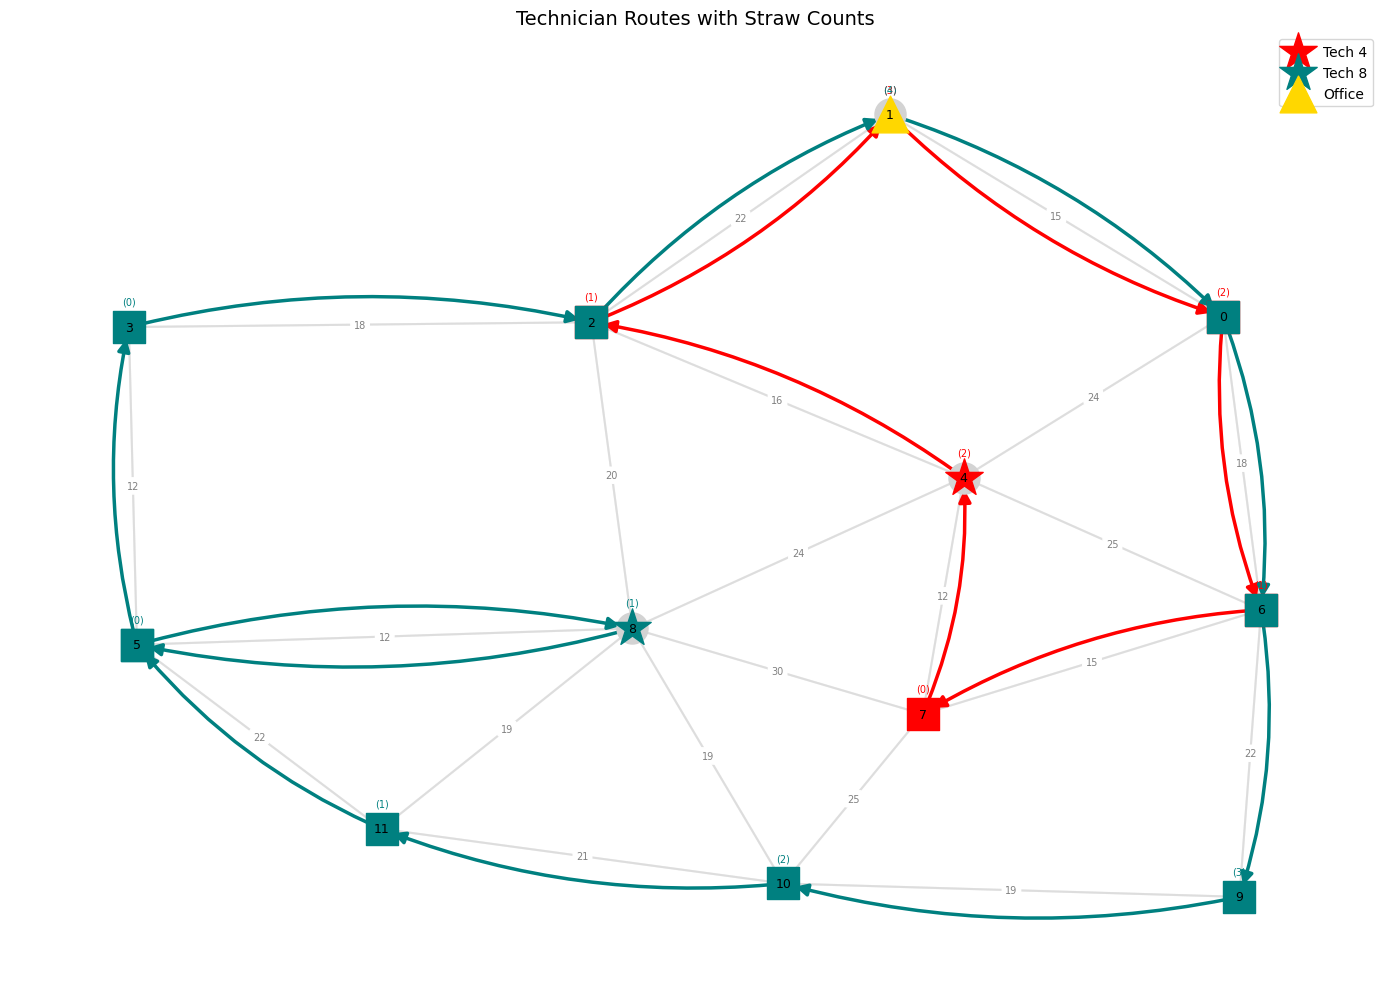

In [ ]:
plot_routes(all_nodes, distance, routes, technicians, office_node, farmers)

In [ ]:
farmers = [1, 2, 3, 6, 7, 9, 10, 11]
technicians = [0, 4, 5]
initial_straws = {0: 1, 4: 1, 5: 1}
refill_amount = {0: 1, 4: 2, 5: 2}
office_node = 8
offices = [8]

routes = solve_technician_routing(
    all_nodes, farmers, technicians, office_node,
    initial_straws, refill_amount, full_distance, full_paths,
    time_limit=60
)

Set parameter TimeLimit to value 60
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  60

Optimize a model with 1022 rows, 507 columns and 4503 nonzeros
Model fingerprint: 0x576bccc3
Variable types: 0 continuous, 507 integer (432 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+06]
  Objective range  [1e+01, 7e+01]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 1e+06]
Presolve removed 39 rows and 45 columns
Presolve time: 0.06s
Presolved: 983 rows, 462 columns, 4296 nonzeros
Variable types: 0 continuous, 462 integer (396 binary)

Root relaxation: objective 2.235000e+02, 82 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd 

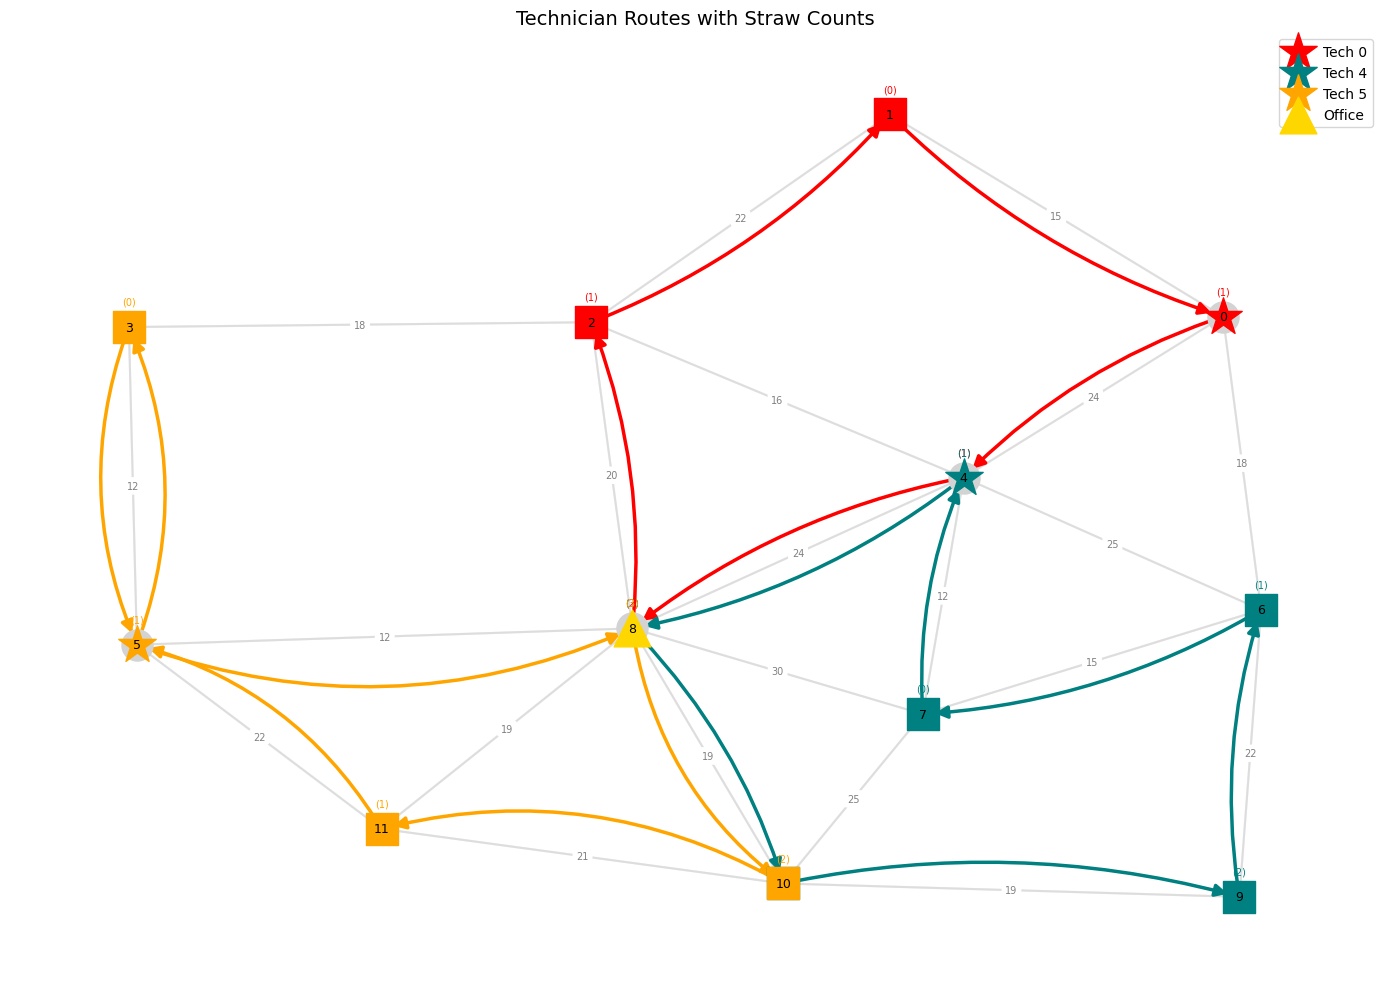

In [ ]:
plot_routes(all_nodes, distance, routes, technicians, office_node, farmers)